# Spotify SHAP Analysis

This notebook uses the Spotify Tracks dataset referenced at Kaggle: `maharshipandya/spotify-tracks-dataset`.

In [5]:
# Dataset is expected at ../data/raw/spotify_tracks/dataset.csv

In [6]:
from pathlib import Path

import pandas as pd

In [7]:
DATASET_RELATIVE_PATH = Path("data/raw/spotify_tracks/dataset.csv")

dataset_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / DATASET_RELATIVE_PATH).exists()
    ),
    None,
)

if dataset_root is None:
    raise FileNotFoundError(
        "Missing data/raw/spotify_tracks/dataset.csv. Run the notebook from the project root or a child directory."
    )

DATASET_PATH = dataset_root / DATASET_RELATIVE_PATH
df = pd.read_csv(DATASET_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]:,} columns from {DATASET_PATH}")
df.head()

Loaded 114,000 rows x 20 columns from /Users/saiashwin/SoundCheck/data/raw/spotify_tracks/dataset.csv


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
# list all track genres and their counts in descending order
track_genre_counts = df['track_genre'].value_counts()
print("List of all track genres and their counts:")
for genre, count in track_genre_counts.items():
    print("-", genre, ":", count)


List of all track genres and their counts:
- acoustic : 1000
- afrobeat : 1000
- alt-rock : 1000
- alternative : 1000
- ambient : 1000
- anime : 1000
- black-metal : 1000
- bluegrass : 1000
- blues : 1000
- brazil : 1000
- breakbeat : 1000
- british : 1000
- cantopop : 1000
- chicago-house : 1000
- children : 1000
- chill : 1000
- classical : 1000
- club : 1000
- comedy : 1000
- country : 1000
- dance : 1000
- dancehall : 1000
- death-metal : 1000
- deep-house : 1000
- detroit-techno : 1000
- disco : 1000
- disney : 1000
- drum-and-bass : 1000
- dub : 1000
- dubstep : 1000
- edm : 1000
- electro : 1000
- electronic : 1000
- emo : 1000
- folk : 1000
- forro : 1000
- french : 1000
- funk : 1000
- garage : 1000
- german : 1000
- gospel : 1000
- goth : 1000
- grindcore : 1000
- groove : 1000
- grunge : 1000
- guitar : 1000
- happy : 1000
- hard-rock : 1000
- hardcore : 1000
- hardstyle : 1000
- heavy-metal : 1000
- hip-hop : 1000
- honky-tonk : 1000
- house : 1000
- idm : 1000
- indian : 1

In [9]:
#total number of artists
total_artists = df['artists'].nunique()
print("Total number of artists:", total_artists)

Total number of artists: 31437


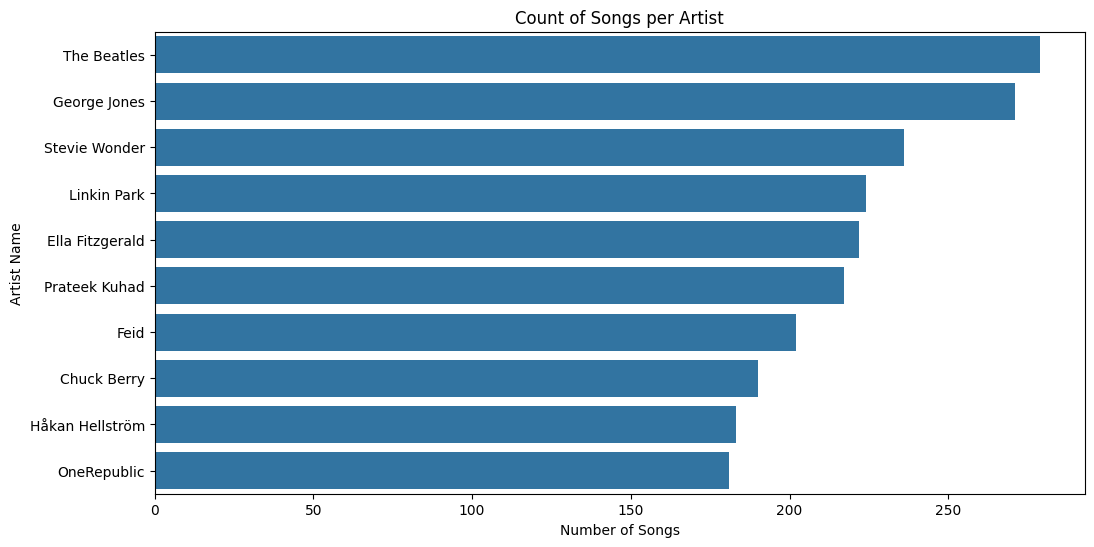

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
#plot for count of top 10 artists
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='artists', order=df['artists'].value_counts().index[:10])
plt.title('Count of Songs per Artist')
plt.xlabel('Number of Songs')
plt.ylabel('Artist Name')
plt.show()


In [11]:
#total number of track_genres
total_track_genres = df['track_genre'].nunique()
print("Total number of track genres:", total_track_genres)

Total number of track genres: 114


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split


def split_artists(artists_value):
    if pd.isna(artists_value):
        return []
    return [artist.strip() for artist in str(artists_value).split(';') if artist.strip()]


def prepare_artist_columns(frame):
    frame = frame.copy()
    frame['artist_list'] = frame['artists'].apply(split_artists)
    frame['main_artist'] = frame['artist_list'].apply(lambda artists: artists[0] if artists else None)
    frame['featured_artists'] = frame['artist_list'].apply(lambda artists: artists[1:])
    frame['num_artists'] = frame['artist_list'].apply(len)
    return frame


def fit_artist_encoder(X_train, y_train):
    train_artists = prepare_artist_columns(X_train)
    exploded = train_artists[['artist_list']].assign(popularity=y_train).explode('artist_list')
    exploded = exploded.dropna(subset=['artist_list'])

    artist_target_mean = exploded.groupby('artist_list')['popularity'].mean().to_dict()
    artist_frequency = exploded.groupby('artist_list').size().to_dict()
    genre_levels = X_train['track_genre'].dropna().astype(str).unique().tolist()

    return {
        'global_target_mean': y_train.mean(),
        'artist_target_mean': artist_target_mean,
        'artist_frequency': artist_frequency,
        'genre_levels': genre_levels,
    }


def transform_artist_features(X, encoder):
    X = prepare_artist_columns(X)
    global_target_mean = encoder['global_target_mean']
    artist_target_mean = encoder['artist_target_mean']
    artist_frequency = encoder['artist_frequency']

    X['main_artist_te'] = X['main_artist'].apply(
        lambda artist: artist_target_mean.get(artist, global_target_mean)
    )
    X['artist_te_mean'] = X['artist_list'].apply(
        lambda artists: np.mean(
            [artist_target_mean.get(artist, global_target_mean) for artist in artists]
            or [global_target_mean]
        )
    )
    X['artist_te_max'] = X['artist_list'].apply(
        lambda artists: np.max(
            [artist_target_mean.get(artist, global_target_mean) for artist in artists]
            or [global_target_mean]
        )
    )
    X['artist_freq_mean'] = X['artist_list'].apply(
        lambda artists: np.mean([artist_frequency.get(artist, 0) for artist in artists] or [0])
    )
    X['artist_freq_max'] = X['artist_list'].apply(
        lambda artists: np.max([artist_frequency.get(artist, 0) for artist in artists] or [0])
    )

    X['explicit'] = X['explicit'].astype(int)

    genre_values = pd.Categorical(
        X['track_genre'].astype(str),
        categories=encoder['genre_levels'],
    )
    genre_dummies = pd.get_dummies(genre_values, prefix='genre')
    genre_dummies.index = X.index

    X = pd.concat(
        [
            X.drop(
                columns=[
                    'artists', 'artist_list', 'main_artist', 'featured_artists', 'track_genre',
                    'track_id', 'album_name', 'track_name',
                ]
            ),
            genre_dummies,
        ],
        axis=1,
    )

    X.columns = [
        re.sub(r'[^a-zA-Z0-9]+', '_', col).strip('_').lower()
        for col in X.columns
    ]

    return X


y = df['popularity'].copy()
X = df.drop(columns=['popularity']).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

artist_encoder = fit_artist_encoder(X_train_raw, y_train)
X_train = transform_artist_features(X_train_raw, artist_encoder)
feature_columns = X_train.columns.tolist()
X_test = transform_artist_features(X_test_raw, artist_encoder).reindex(
    columns=feature_columns,
    fill_value=0,
)

artist_preview = prepare_artist_columns(df[['artists']].head(5))[
    ['artists', 'main_artist', 'featured_artists', 'num_artists']
]

display(artist_preview)
display(
    X_train[
        [
            'num_artists', 'main_artist_te', 'artist_te_mean', 'artist_te_max',
            'artist_freq_mean', 'artist_freq_max',
        ]
    ].head()
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')


set()


,artists,main_artist,featured_artists,num_artists
0,Gen Hoshino,Gen Hoshino,[],1
1,Ben Woodward,Ben Woodward,[],1
2,Ingrid Michaelson;ZAYN,Ingrid Michaelson,[ZAYN],2
3,Kina Grannis,Kina Grannis,[],1
4,Chord Overstreet,Chord Overstreet,[],1


,num_artists,main_artist_te,artist_te_mean,artist_te_max,artist_freq_mean,artist_freq_max
41996,1,22.000000,22.000000,22.000000,1.0,1
76471,1,23.125000,23.125000,23.125000,8.0,8
54809,1,20.882353,20.882353,20.882353,17.0,17
16326,2,0.000000,0.000000,0.000000,3.5,6
109799,1,25.931818,25.931818,25.931818,132.0,132


Train shape: (79800, 147)
Test shape: (34200, 147)


In [13]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [14]:
models = {
    'xgboost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    ),
    'lightgbm': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    'catboost': CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        loss_function='RMSE',
        verbose=0,
    ),
}

metrics = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    metrics.append({
        'model': model_name,
        'RMSE': rmse,
        'MSE': mse,
        'R2': r2,
    })

metrics_df = pd.DataFrame(metrics).sort_values('RMSE').reset_index(drop=True)
metrics_df


,model,RMSE,MSE,R2
0,xgboost,14.348770,205.887192,0.583919
1,lightgbm,14.512676,210.617756,0.574359
2,catboost,14.659312,214.895440,0.565714


In [15]:
import shap

xgb_model = models['xgboost']
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values = shap_explainer(shap_sample)

mean_abs_shap = (
    pd.DataFrame({
        'feature': shap_sample.columns,
        'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print(f'SHAP sample size: {len(shap_sample)}')
mean_abs_shap.head(15)


/Users/saiashwin/SoundCheck/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP sample size: 1000


,feature,mean_abs_shap
0,artist_te_mean,12.268234
1,artist_te_max,4.089892
2,main_artist_te,1.022157
3,artist_freq_mean,0.393655
4,speechiness,0.239573
5,loudness,0.194473
6,acousticness,0.193430
7,liveness,0.188125
8,num_artists,0.171311
9,duration_ms,0.164915


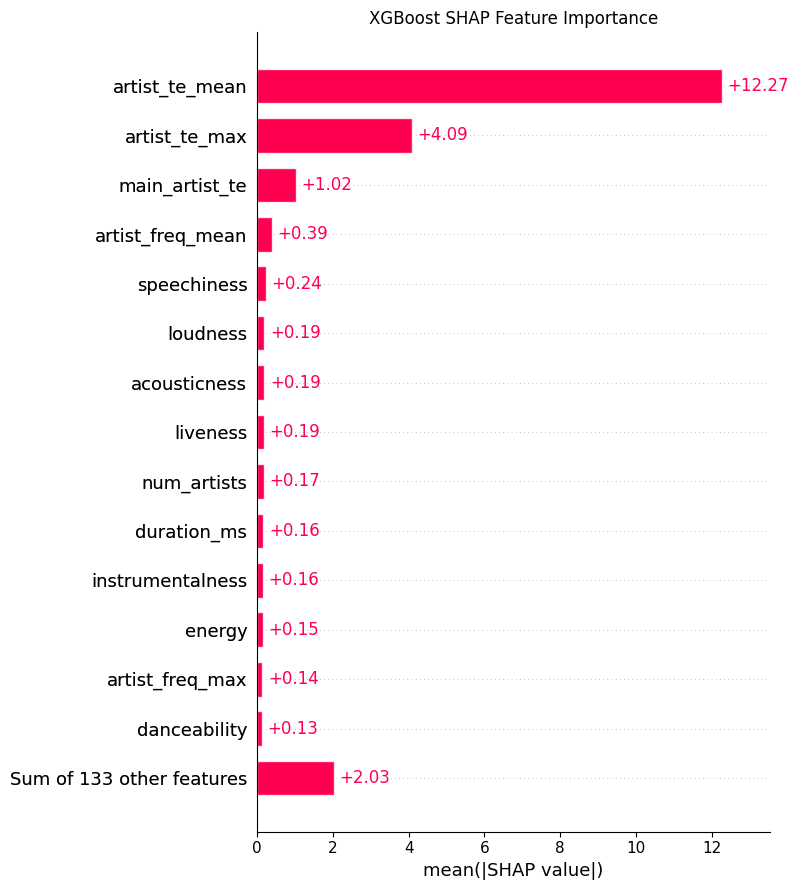

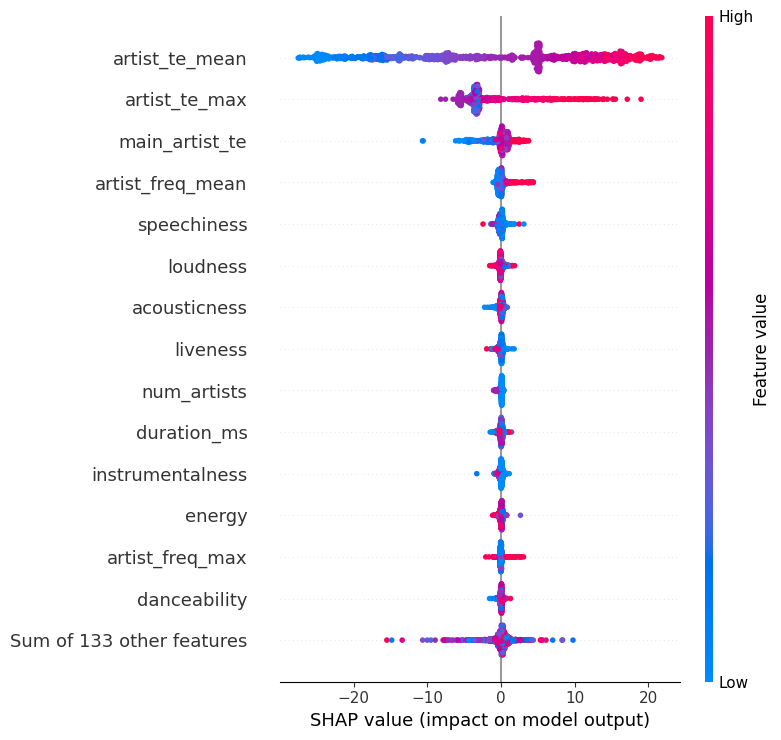

Local explanation for test row: 18948


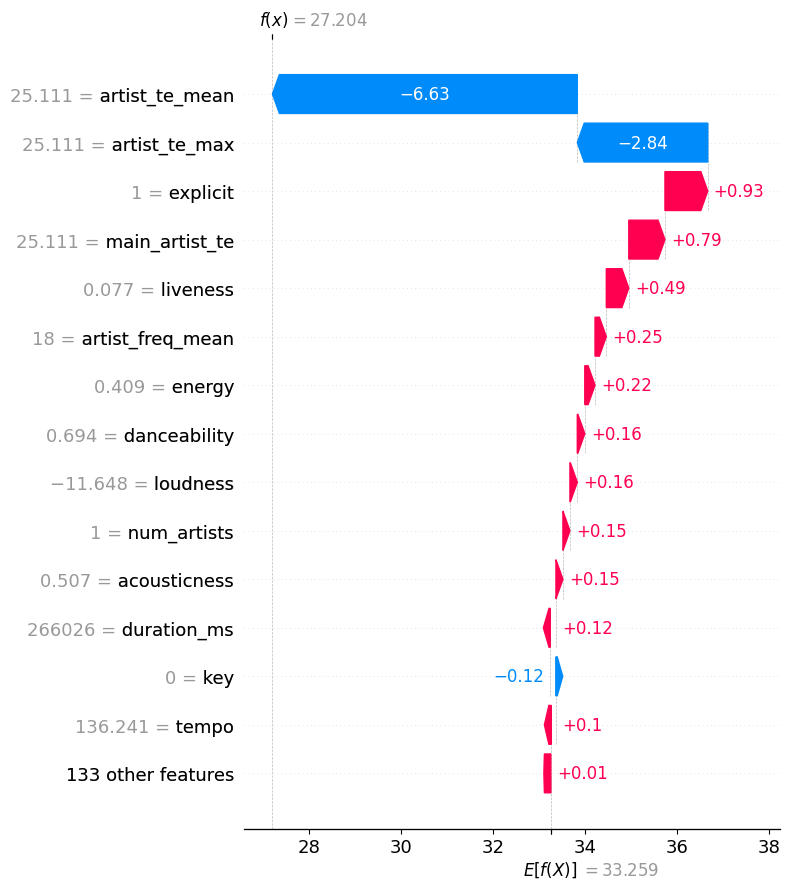

In [16]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('XGBoost SHAP Feature Importance')
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

sample_row = shap_sample.index[0]
print(f'Local explanation for test row: {sample_row}')
shap.plots.waterfall(shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.show()


## Main takeaway

The model is relying very heavily on artist-related features, much more than on audio features.

From the bar plot:

* artist_te_mean is by far the most important feature:
    If a song has multiple artists, this is the average of their target-encoding values. On average, how successful are the artists on this track?
* then artist_te_max: 
    This is the highest target-encoding value among all artists on the song. Is there at least one highly successful artist on this track?
* then main_artist_te:
    This is the average target value of the main artist based on past songs in the training data.

    So if the main artist usually has songs with high popularity, this value will be high.
    If the main artist usually has low-popularity songs, this value will be low.
* after that, everything else is much smaller

This means the model is learning that who made the song matters much more for predicted popularity than the song’s audio properties.

What that says about the data

It suggests that the dataset has a strong pattern like:

* songs from artists with historically high popularity tend to get predicted higher
* songs from artists with historically low popularity tend to get predicted lower

So the model is capturing artist popularity/history effect very strongly.

The SHAP analysis shows that artist-derived target encoding features dominate the model’s predictions. In particular, artist_te_mean and artist_te_max have substantially larger importance than all acoustic features, indicating that the model relies more on historical artist-level popularity patterns than on the musical characteristics of the track itself. Among the audio variables, features such as speechiness, loudness, acousticness, liveness, and tempo contribute only marginally. This suggests that, in the current dataset and feature setup, artist identity is a much stronger determinant of predicted popularity than audio content.

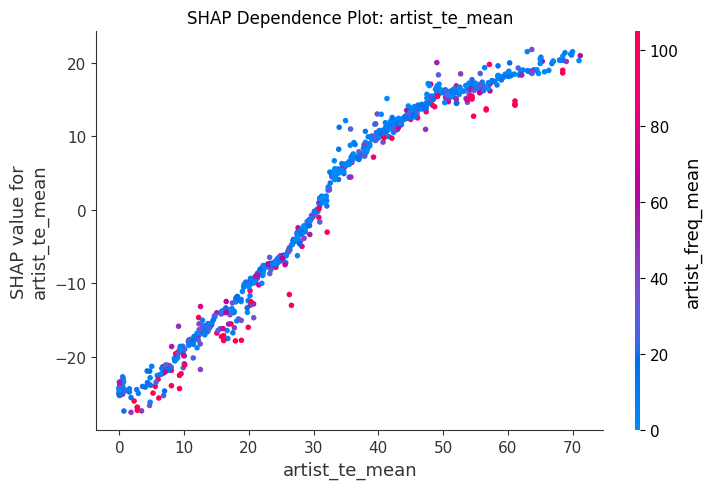

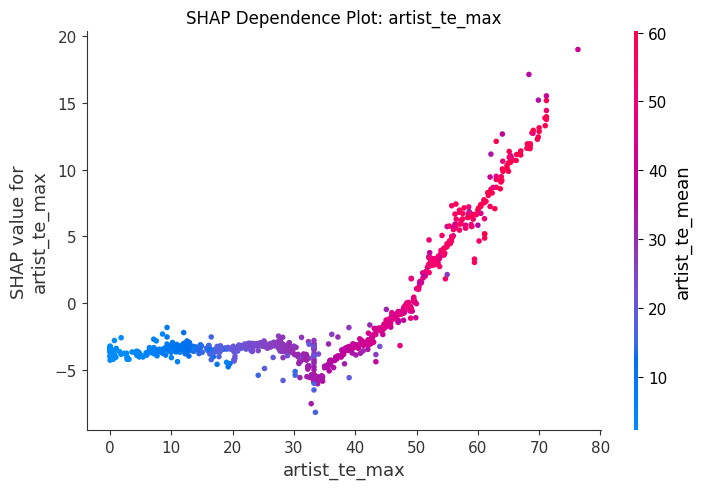

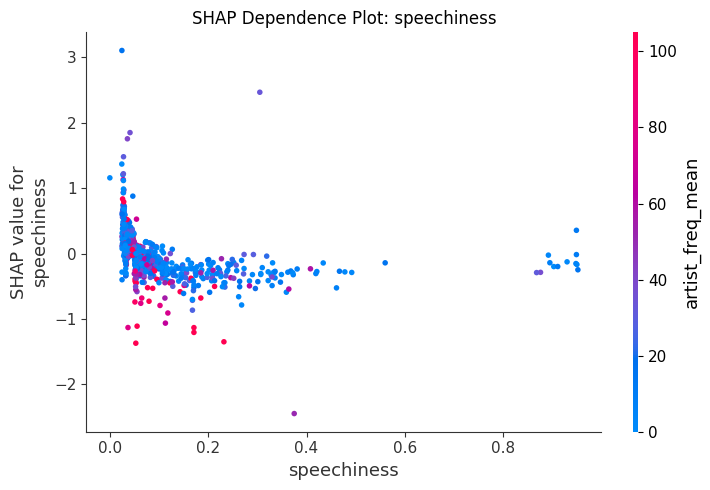

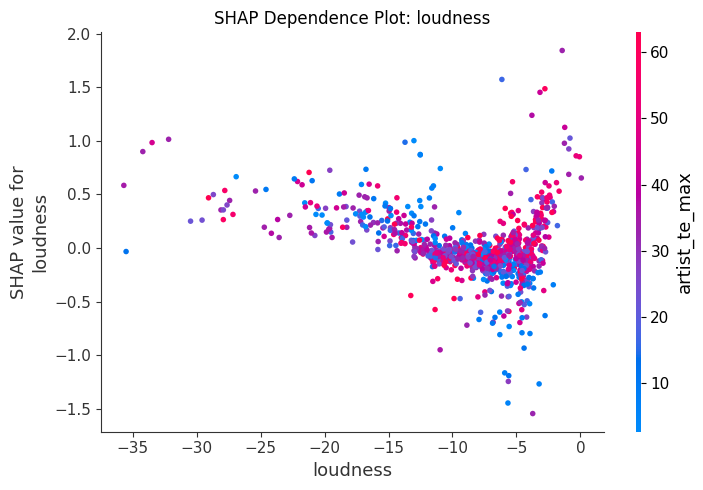

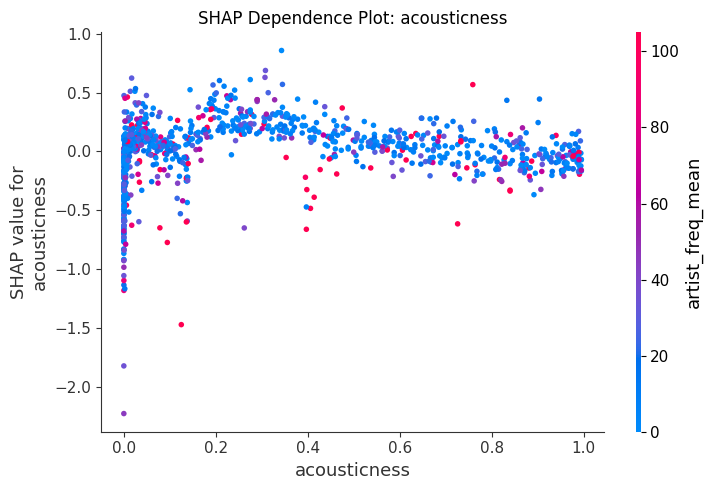

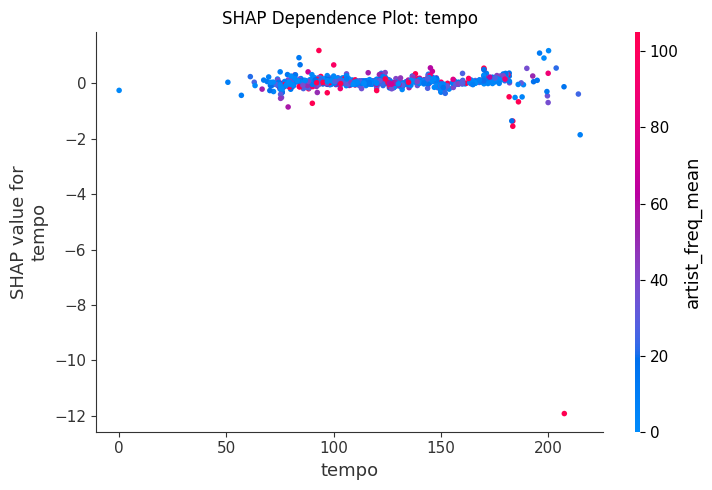

In [17]:
dependence_features = [
    'artist_te_mean',
    'artist_te_max',
    'speechiness',
    'loudness',
    'acousticness',
    'tempo',
]

for feature_name in dependence_features:
    shap.dependence_plot(
        feature_name,
        shap_values.values,
        shap_sample,
        interaction_index='auto',
        show=False,
    )
    plt.title(f'SHAP Dependence Plot: {feature_name}')
    plt.tight_layout()
    plt.show()


In [18]:
xgb_predictions = pd.Series(predictions['xgboost'], index=X_test.index, name='predicted_popularity')

high_idx = xgb_predictions.idxmax()
low_idx = xgb_predictions.idxmin()
median_prediction = xgb_predictions.median()
medium_idx = (xgb_predictions - median_prediction).abs().idxmin()

selected_song_indices = {
    'high_predicted_popularity': high_idx,
    'medium_predicted_popularity': medium_idx,
    'low_predicted_popularity': low_idx,
}

selected_song_summary = pd.DataFrame([
    {
        'bucket': bucket,
        'track_name': X_test_raw.loc[idx, 'track_name'],
        'artists': X_test_raw.loc[idx, 'artists'],
        'genre': X_test_raw.loc[idx, 'track_genre'],
        'actual_popularity': y_test.loc[idx],
        'predicted_popularity': xgb_predictions.loc[idx],
    }
    for bucket, idx in selected_song_indices.items()
])

display(selected_song_summary)


,bucket,track_name,artists,genre,actual_popularity,predicted_popularity
0,high_predicted_popularity,Moscow Mule,Bad Bunny,latino,94,94.548988
1,medium_predicted_popularity,Que Murmuren,Marco Antonio Muñiz,rock-n-roll,29,33.482094
2,low_predicted_popularity,Poblado - Remix,J Balvin;KAROL G;Nicky Jam;Crissin;Totoy El Fr...,latin,0,-5.577135


Local SHAP waterfall: high_predicted_popularity


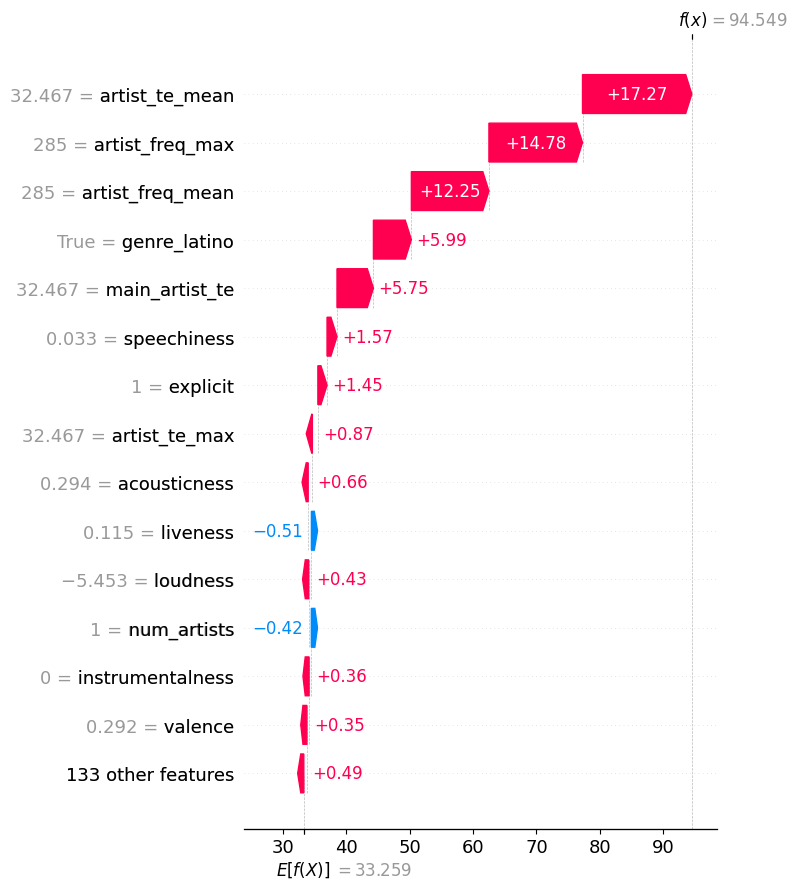

Local SHAP waterfall: medium_predicted_popularity


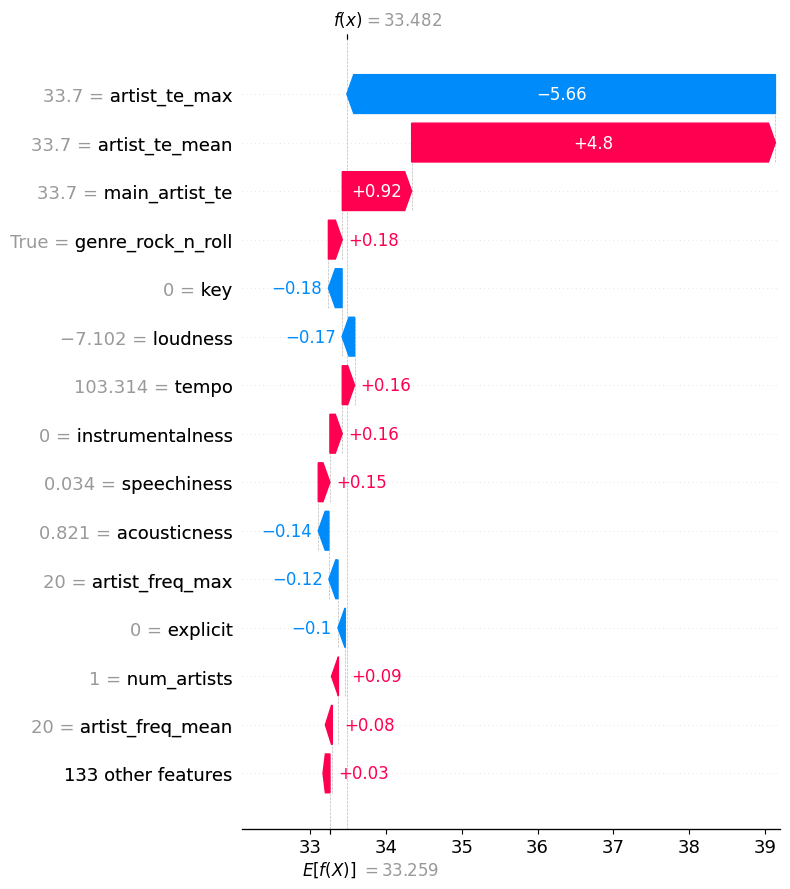

Local SHAP waterfall: low_predicted_popularity


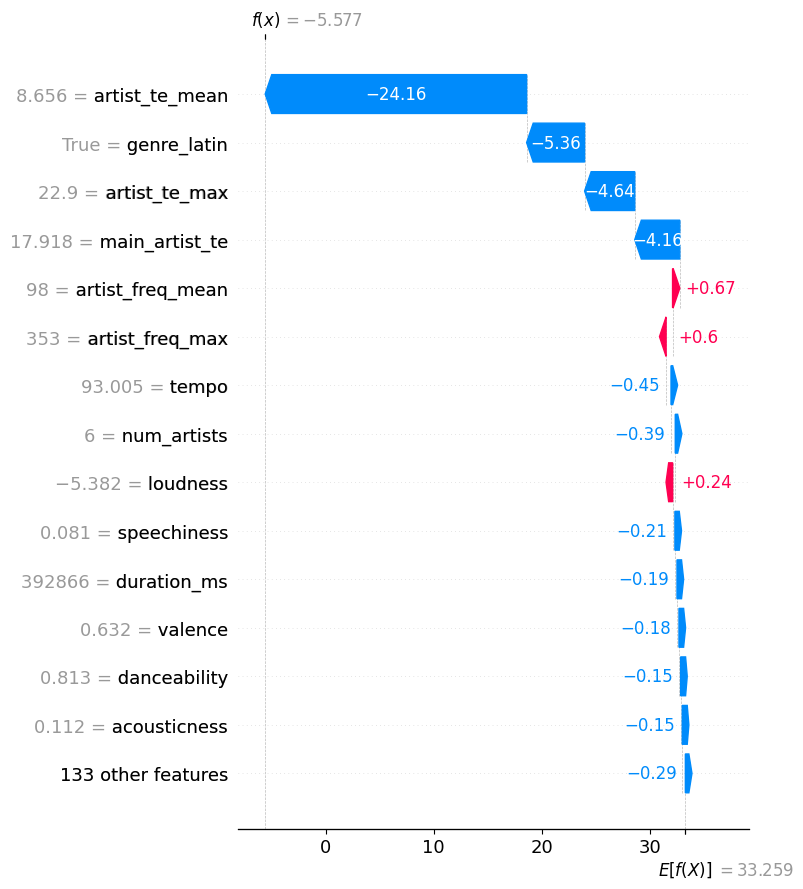

In [19]:
selected_feature_rows = X_test.loc[list(selected_song_indices.values())]
selected_shap_values = shap_explainer(selected_feature_rows)

for bucket, row_position in zip(selected_song_summary['bucket'], range(len(selected_feature_rows))):
    print(f'Local SHAP waterfall: {bucket}')
    shap.plots.waterfall(selected_shap_values[row_position], max_display=15, show=False)
    plt.tight_layout()
    plt.show()


,feature_group,total_mean_abs_shap,avg_mean_abs_shap,feature_count,share_of_total
0,artist features,18.085388,3.014231,6,0.840113
1,audio features,1.889892,0.134992,14,0.087790
2,genre features,1.552056,0.012221,127,0.072097


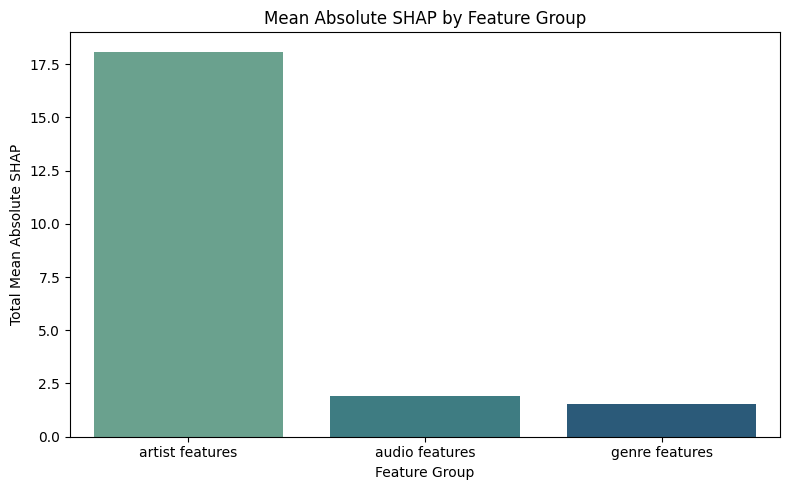

In [20]:
artist_feature_columns = [
    'main_artist_te',
    'num_artists',
    'artist_te_mean',
    'artist_te_max',
    'artist_freq_mean',
    'artist_freq_max',
]
genre_feature_columns = [column for column in X_train.columns if column.startswith('genre_')]
audio_feature_columns = [
    column for column in X_train.columns
    if column not in artist_feature_columns + genre_feature_columns
]

feature_group_lookup = {}
for column in artist_feature_columns:
    feature_group_lookup[column] = 'artist features'
for column in genre_feature_columns:
    feature_group_lookup[column] = 'genre features'
for column in audio_feature_columns:
    feature_group_lookup[column] = 'audio features'

group_shap_df = mean_abs_shap.copy()
group_shap_df['feature_group'] = group_shap_df['feature'].map(feature_group_lookup)
group_shap_summary = (
    group_shap_df.groupby('feature_group')['mean_abs_shap']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={
        'sum': 'total_mean_abs_shap',
        'mean': 'avg_mean_abs_shap',
        'count': 'feature_count',
    })
    .sort_values('total_mean_abs_shap', ascending=False)
    .reset_index()
)
group_shap_summary['share_of_total'] = (
    group_shap_summary['total_mean_abs_shap'] / group_shap_summary['total_mean_abs_shap'].sum()
)

display(group_shap_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=group_shap_summary,
    x='feature_group',
    y='total_mean_abs_shap',
    hue='feature_group',
    palette='crest',
    legend=False,
)
plt.title('Mean Absolute SHAP by Feature Group')
plt.xlabel('Feature Group')
plt.ylabel('Total Mean Absolute SHAP')
plt.tight_layout()
plt.show()


In [21]:
def build_xgb_regressor():
    return XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
    )

ablation_feature_sets = {
    'full_model': X_train.columns.tolist(),
    'without_artist_features': [
        column for column in X_train.columns if column not in artist_feature_columns
    ],
    'audio_only_model': audio_feature_columns,
}

ablation_rows = []
ablation_predictions = {}

for ablation_name, feature_subset in ablation_feature_sets.items():
    ablation_model = build_xgb_regressor()
    ablation_model.fit(X_train[feature_subset], y_train)
    ablation_pred = ablation_model.predict(X_test[feature_subset])
    ablation_predictions[ablation_name] = ablation_pred

    ablation_mse = mean_squared_error(y_test, ablation_pred)
    ablation_rows.append({
        'model_variant': ablation_name,
        'feature_count': len(feature_subset),
        'RMSE': ablation_mse ** 0.5,
        'MSE': ablation_mse,
        'R2': r2_score(y_test, ablation_pred),
    })

ablation_metrics_df = pd.DataFrame(ablation_rows).sort_values('RMSE').reset_index(drop=True)
ablation_metrics_df


,model_variant,feature_count,RMSE,MSE,R2
0,full_model,147,14.348770,205.887192,0.583919
1,without_artist_features,141,18.481149,341.552856,0.309750
2,audio_only_model,14,19.660352,386.529449,0.218856


These results give a very clear story.

## Main conclusion

Your model’s predictive power comes **mostly from artist-related features**.
Audio features add some value, and genre features add only a small amount.

---

## 1. SHAP group importance conclusion

From the SHAP grouping:

* **artist features:** 84.9% of total importance
* **audio features:** 8.7%
* **genre features:** 6.4%

This means the model is relying overwhelmingly on **artist-history signals**.

### What this says in simple words

The model is mainly learning:

> “Songs by artists who have historically performed well are more likely to be predicted as popular.”

rather than:

> “This song is popular because of its musical characteristics or genre.”

So the strongest signal in your dataset is **artist reputation / prior performance**, not the sound profile of the track.

---

## 2. Per-feature-group efficiency

The `avg_mean_abs_shap` values are also very important:

* **artist features:** 3.09 across only 6 features
* **audio features:** 0.136 across 14 features
* **genre features:** 0.012 across 114 features

This means artist features are not only the biggest group overall, but also **extremely strong per feature**.

### Interpretation

* each artist feature carries a lot of predictive information
* audio features are individually weak to moderate
* genre features are very diffuse and weak individually

So even though you have 114 genre columns, together they still contribute less than the artist group.

That suggests genre is not a major standalone driver in this setup.

---

## 3. Model ablation conclusion

Now the most important part is the model comparison.

### Full model

* RMSE = **14.36**
* R² = **0.583**

### Without artist features

* RMSE = **18.56**
* R² = **0.304**

### Audio-only model

* RMSE = **19.66**
* R² = **0.219**

---

## 4. What happens when artist features are removed?

When you remove artist features:

* RMSE gets much worse: **14.36 → 18.56**
* R² drops sharply: **0.583 → 0.304**

This is a major performance loss.

### Interpretation

Artist features are not just slightly useful.
They are the **main reason** the model performs well.

So the model’s ability to explain popularity is strongly tied to knowing the historical strength of the artist.

---

## 5. What do audio features contribute?

Compare:

* without artist features: R² = **0.304**
* audio only: R² = **0.219**

This suggests that once artist features are removed, the remaining non-artist features still retain some predictive signal, and audio features do explain part of popularity.

But their contribution is clearly much smaller than artist features.

### Interpretation

Audio properties matter, but they are **secondary predictors**.

The model can still learn something from them, but not nearly as much as from artist information.

---

## 6. What do genre features contribute?

Since:

* audio-only model has R² = **0.219**
* without artist features has R² = **0.304**

the gap is about **0.085 R²**

That suggests the extra non-audio features in the “without artist” model, especially genre, contribute **some additional value**, but not a lot.

Combined with SHAP:

* genre share is only **6.4%**
* average genre feature impact is tiny

### Interpretation

Genre helps a little at group level, but individual genre dummy variables are weak predictors.

So genre is likely a **supporting signal**, not a dominant one.

---

## 7. Strongest report-level inference

A very solid conclusion is:

> The model’s predictive performance is driven primarily by artist-derived features, which account for nearly 85% of total SHAP importance and whose removal causes a substantial drop in model accuracy. Audio features provide secondary predictive value, while genre features contribute only marginally. This indicates that the model is learning popularity largely through artist-level prior success rather than through the acoustic or stylistic characteristics of the track alone.

---

## 8. What this means conceptually

Your model is currently better at answering:

> “Will this song be popular given who the artists are?”

than:

> “Will this song be popular based on how it sounds?”

That is an important distinction.

---

## 9. Possible interpretation risk

There is also a caution here:

Because artist target-encoded features are so dominant, the model may be learning a kind of **artist prior bias**.
That is useful for prediction, but it reduces the role of music-content features.

So if your project goal is:

* **prediction accuracy**, this is acceptable and even expected
* **understanding musical drivers of popularity**, then this model is less suitable in its current form

---

## 10. Crisp conclusions you can write

You can state these:

1. **Artist-related features are the dominant predictive signal**, contributing about 85% of total SHAP importance.
2. **Removing artist features substantially degrades performance**, showing that the model depends strongly on artist-level historical information.
3. **Audio features have moderate but clearly smaller predictive value** than artist features.
4. **Genre features contribute the least**, despite having many encoded columns.
5. The full model is therefore learning **artist-driven popularity patterns more than content-driven popularity patterns**.

---

## 11. One extra nice inference

Because the full model R² is **0.583** and without artist it is **0.304**, you can say:

* roughly half of the explained variance in the full model is tied to artist-related information

Not mathematically exact as a causal claim, but as an interpretation of the ablation, it is fair to say that **artist information accounts for a large share of the model’s explanatory power**.

---

## 12. Final simple summary

In simple words:

* **artist matters the most**
* **audio matters a little**
* **genre matters the least**
* your best model predicts popularity mainly from **who made the song**, not mainly from **how the song sounds**

A strong next step would be to build a **content-focused model without artist target encoding** if you want to study what musical characteristics drive popularity.


In [22]:
def compute_subset_shap(feature_frame, sample_limit=2000, random_state=42):
    if len(feature_frame) == 0:
        raise ValueError('Subset has no rows.')

    if sample_limit is None or len(feature_frame) <= sample_limit:
        subset_sample = feature_frame.copy()
    else:
        subset_sample = feature_frame.sample(n=sample_limit, random_state=random_state)

    subset_explanation = shap_explainer(subset_sample)
    subset_mean_abs = (
        pd.DataFrame({
            'feature': subset_sample.columns,
            'mean_abs_shap': np.abs(subset_explanation.values).mean(axis=0),
        })
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    return subset_sample, subset_explanation, subset_mean_abs


def plot_mean_abs_shap(summary_df, title, top_n=15, color='steelblue'):
    plot_df = summary_df.head(top_n).iloc[::-1]
    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    plt.barh(plot_df['feature'], plot_df['mean_abs_shap'], color=color)
    plt.title(title)
    plt.xlabel('Mean absolute SHAP value')
    plt.tight_layout()
    plt.show()


def summarize_feature_direction(feature_name, feature_frame, subset_explanation):
    feature_idx = feature_frame.columns.get_loc(feature_name)
    shap_contrib = pd.Series(subset_explanation.values[:, feature_idx], index=feature_frame.index)
    return feature_frame[feature_name].corr(shap_contrib)


Analysis 1: SHAP on high-artist-strength songs
Top 10% threshold for artist_te_mean: 55.125
Subset size: 3422 rows | SHAP sample size: 2000 rows


,feature,mean_abs_shap
0,artist_te_mean,18.463757
1,artist_te_max,8.846869
2,main_artist_te,1.707489
3,artist_freq_mean,0.531289
4,speechiness,0.231879
5,liveness,0.193496
6,genre_pop,0.189014
7,acousticness,0.187307
8,loudness,0.176294
9,duration_ms,0.169951


,feature,mean_abs_shap
0,speechiness,0.231879
1,liveness,0.193496
2,genre_pop,0.189014
3,acousticness,0.187307
4,loudness,0.176294
5,duration_ms,0.169951
6,energy,0.159817
7,explicit,0.157108
8,instrumentalness,0.133136
9,danceability,0.119611


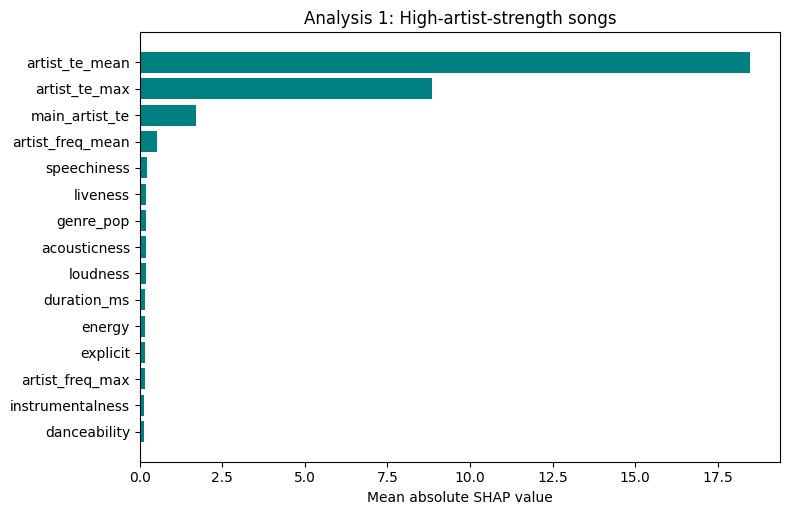

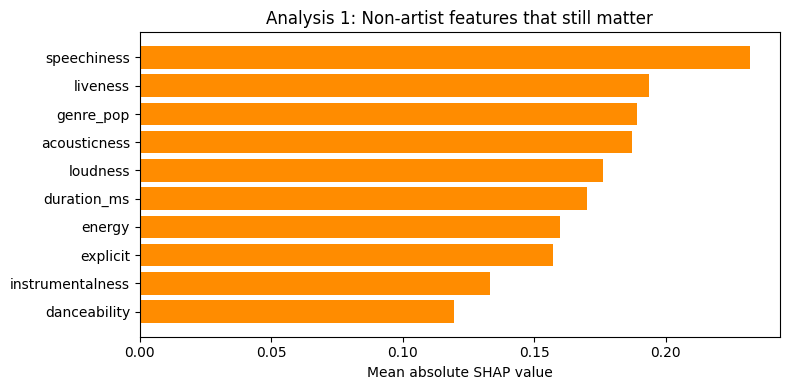

In [23]:
print('Analysis 1: SHAP on high-artist-strength songs')

analysis1_threshold = X_test['artist_te_mean'].quantile(0.90)
analysis1_features = X_test.loc[X_test['artist_te_mean'] >= analysis1_threshold]
analysis1_sample, analysis1_explanation, analysis1_mean_abs = compute_subset_shap(
    analysis1_features,
    sample_limit=2000,
)
analysis1_non_artist = analysis1_mean_abs[
    ~analysis1_mean_abs['feature'].isin(artist_feature_columns)
].reset_index(drop=True)

print(f'Top 10% threshold for artist_te_mean: {analysis1_threshold:.3f}')
print(f'Subset size: {len(analysis1_features)} rows | SHAP sample size: {len(analysis1_sample)} rows')
display(analysis1_mean_abs.head(15))
display(analysis1_non_artist.head(10))
plot_mean_abs_shap(
    analysis1_mean_abs,
    'Analysis 1: High-artist-strength songs',
    top_n=15,
    color='teal',
)
plot_mean_abs_shap(
    analysis1_non_artist,
    'Analysis 1: Non-artist features that still matter',
    top_n=10,
    color='darkorange',
)


Analysis 2: SHAP on collaboration songs only
Collaboration subset size: 9033 rows | SHAP sample size: 2000 rows


,feature,mean_abs_shap
0,artist_te_mean,12.384654
1,artist_te_max,4.374856


,feature,mean_abs_shap
0,artist_te_mean,12.384654
1,artist_te_max,4.374856
2,main_artist_te,1.163421
3,artist_freq_mean,0.483036
4,num_artists,0.359334
5,artist_freq_max,0.293486
6,speechiness,0.242171
7,liveness,0.225611
8,loudness,0.216326
9,acousticness,0.199990


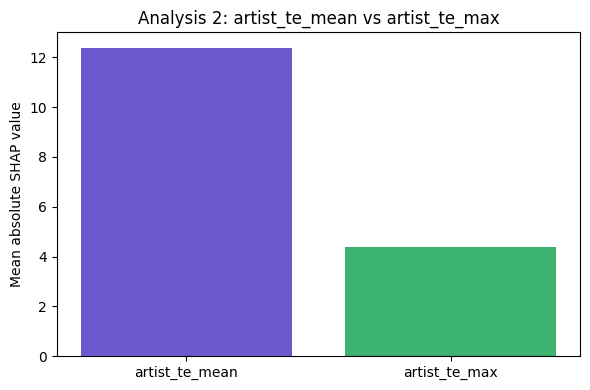

Dominant artist-strength driver within collaboration songs: artist_te_mean


In [24]:
print('Analysis 2: SHAP on collaboration songs only')

analysis2_features = X_test.loc[X_test['num_artists'] > 1]
analysis2_sample, analysis2_explanation, analysis2_mean_abs = compute_subset_shap(
    analysis2_features,
    sample_limit=2000,
)
analysis2_artist_compare = analysis2_mean_abs[
    analysis2_mean_abs['feature'].isin(['artist_te_mean', 'artist_te_max'])
].reset_index(drop=True)

print(f'Collaboration subset size: {len(analysis2_features)} rows | SHAP sample size: {len(analysis2_sample)} rows')
display(analysis2_artist_compare)
display(analysis2_mean_abs.head(15))

plt.figure(figsize=(6, 4))
plt.bar(
    analysis2_artist_compare['feature'],
    analysis2_artist_compare['mean_abs_shap'],
    color=['slateblue', 'mediumseagreen'],
)
plt.title('Analysis 2: artist_te_mean vs artist_te_max')
plt.ylabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

analysis2_driver = analysis2_artist_compare.sort_values('mean_abs_shap', ascending=False).iloc[0]['feature']
print(f'Dominant artist-strength driver within collaboration songs: {analysis2_driver}')


Analysis 3: Single vs collaboration comparison
Single-artist rows: 25166 | Collaboration rows: 9033


,feature,single_artist_mean_abs_shap,collaboration_mean_abs_shap,abs_gap,higher_group
0,artist_te_mean,11.774664,12.384654,0.609990,collaboration
1,artist_te_max,3.920637,4.374856,0.454219,collaboration
2,num_artists,0.104674,0.359334,0.254660,collaboration
3,main_artist_te,0.920062,1.163421,0.243359,collaboration
4,artist_freq_max,0.124651,0.293486,0.168835,collaboration
5,genre_house,0.025532,0.153074,0.127542,collaboration
6,genre_rock,0.166770,0.073251,0.093519,single_artist
7,genre_latino,0.035326,0.119632,0.084306,collaboration
8,genre_latin,0.072509,0.148883,0.076374,collaboration
9,genre_edm,0.025849,0.065317,0.039468,collaboration


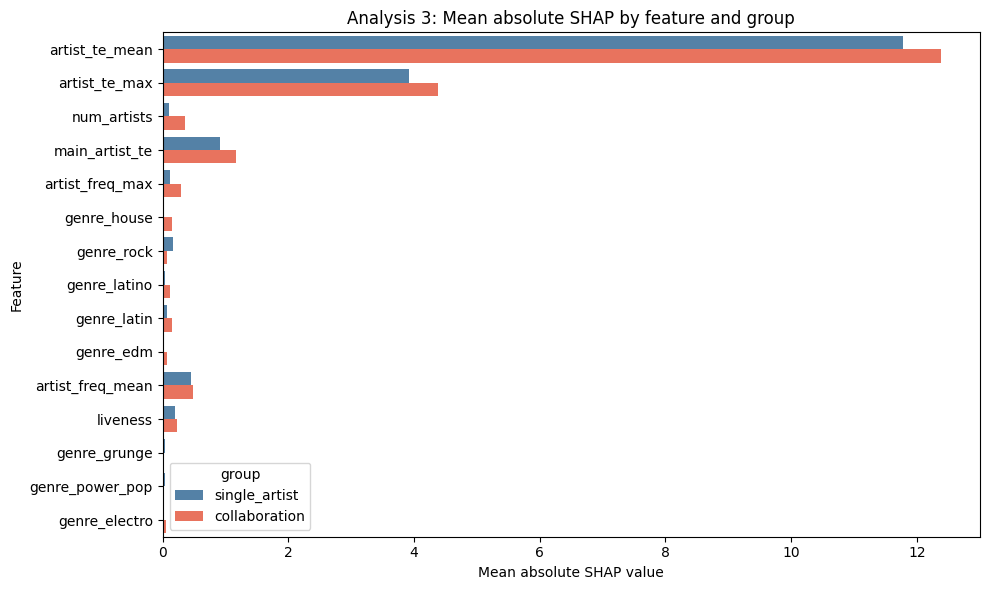

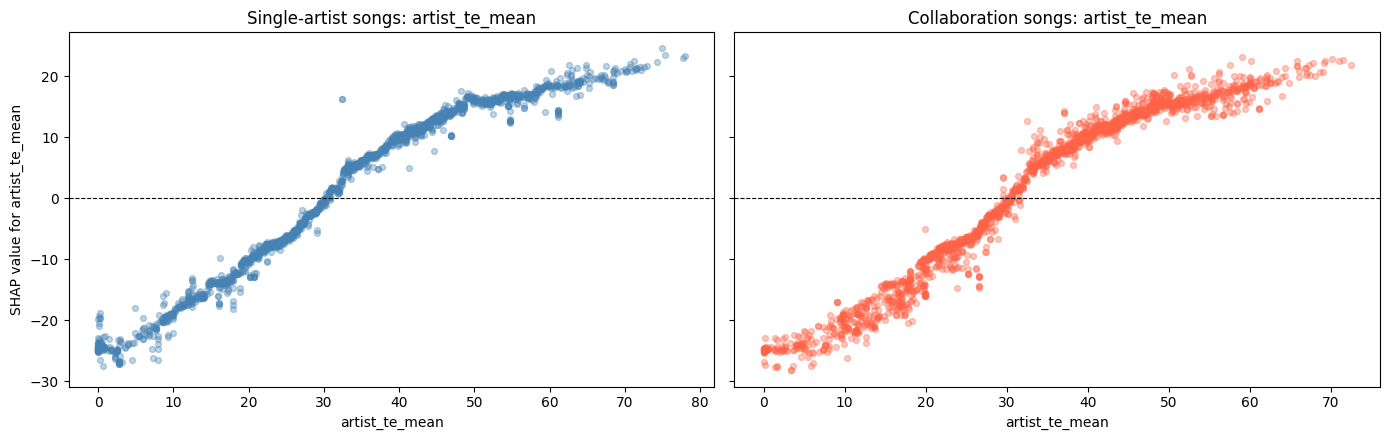

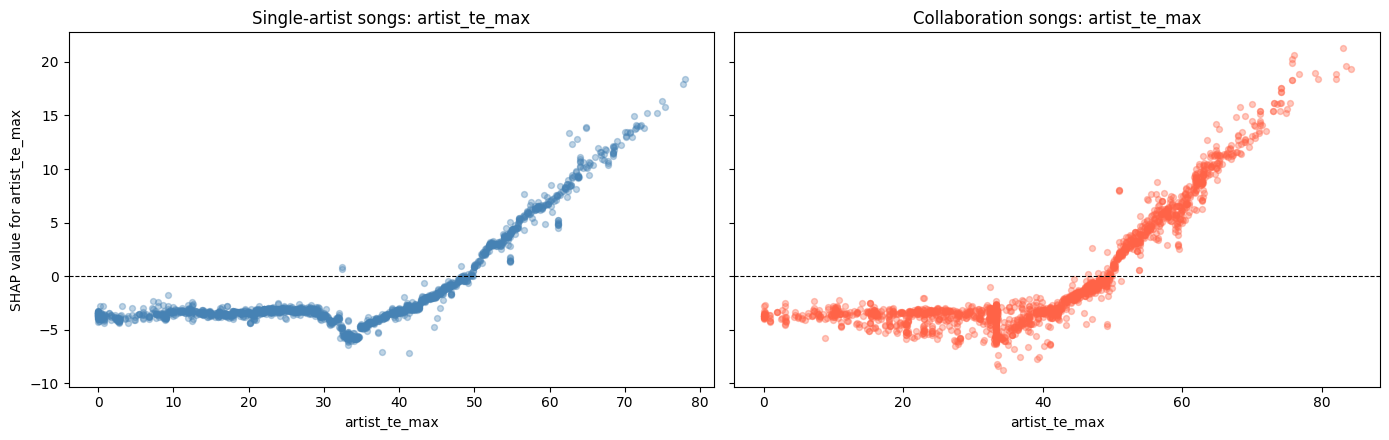

In [25]:
print('Analysis 3: Single vs collaboration comparison')

single_artist_features = X_test.loc[X_test['num_artists'] == 1]
collaboration_features = X_test.loc[X_test['num_artists'] > 1]

single_artist_sample, single_artist_explanation, single_artist_mean_abs = compute_subset_shap(
    single_artist_features,
    sample_limit=2000,
)
collaboration_sample, collaboration_explanation, collaboration_mean_abs = compute_subset_shap(
    collaboration_features,
    sample_limit=2000,
)

analysis3_compare = (
    single_artist_mean_abs.rename(columns={'mean_abs_shap': 'single_artist_mean_abs_shap'})
    .merge(
        collaboration_mean_abs.rename(columns={'mean_abs_shap': 'collaboration_mean_abs_shap'}),
        on='feature',
        how='outer',
    )
    .fillna(0)
)
analysis3_compare['abs_gap'] = (
    analysis3_compare['collaboration_mean_abs_shap'] - analysis3_compare['single_artist_mean_abs_shap']
).abs()
analysis3_compare['higher_group'] = np.where(
    analysis3_compare['collaboration_mean_abs_shap'] > analysis3_compare['single_artist_mean_abs_shap'],
    'collaboration',
    'single_artist',
)
analysis3_top_gap = analysis3_compare.sort_values('abs_gap', ascending=False).head(15).reset_index(drop=True)

print(f'Single-artist rows: {len(single_artist_features)} | Collaboration rows: {len(collaboration_features)}')
display(analysis3_top_gap)

analysis3_plot_df = analysis3_top_gap.melt(
    id_vars='feature',
    value_vars=['single_artist_mean_abs_shap', 'collaboration_mean_abs_shap'],
    var_name='group',
    value_name='mean_abs_shap',
)
analysis3_plot_df['group'] = analysis3_plot_df['group'].map({
    'single_artist_mean_abs_shap': 'single_artist',
    'collaboration_mean_abs_shap': 'collaboration',
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=analysis3_plot_df,
    y='feature',
    x='mean_abs_shap',
    hue='group',
    palette={'single_artist': 'steelblue', 'collaboration': 'tomato'},
)
plt.title('Analysis 3: Mean absolute SHAP by feature and group')
plt.xlabel('Mean absolute SHAP value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

for feature_name in ['artist_te_mean', 'artist_te_max']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

    for ax, feature_frame, subset_explanation, title, color in [
        (axes[0], single_artist_sample, single_artist_explanation, 'Single-artist songs', 'steelblue'),
        (axes[1], collaboration_sample, collaboration_explanation, 'Collaboration songs', 'tomato'),
    ]:
        feature_idx = feature_frame.columns.get_loc(feature_name)
        shap_contrib = subset_explanation.values[:, feature_idx]
        ax.scatter(feature_frame[feature_name], shap_contrib, alpha=0.35, s=18, color=color)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f'{title}: {feature_name}')
        ax.set_xlabel(feature_name)

    axes[0].set_ylabel(f'SHAP value for {feature_name}')
    plt.tight_layout()
    plt.show()


Analysis 4: Waterfall plots for selected songs


,bucket,track_name,artists,num_artists,genre,actual_popularity,predicted_popularity
0,high_predicted_single_artist_song,Moscow Mule,Bad Bunny,1,latino,94,94.548988
1,high_predicted_collaboration_song,DÁKITI,Bad Bunny;Jhay Cortez,2,reggaeton,80,87.835129
2,low_predicted_collaboration_song,Poblado - Remix,J Balvin;KAROL G;Nicky Jam;Crissin;Totoy El Fr...,6,latin,0,-5.577135


Waterfall explanation: high_predicted_single_artist_song


,feature,feature_value,shap_value
16,artist_te_mean,32.466667,17.267656
19,artist_freq_max,285,14.781650
18,artist_freq_mean,285.0,12.252193
87,genre_latino,True,5.991901
15,main_artist_te,32.466667,5.753404


,feature,feature_value,shap_value
10,liveness,0.115,-0.512983
14,num_artists,1,-0.418540
2,danceability,0.804,-0.283498
137,broad_genre_pop,False,-0.032715
25,genre_pop,False,-0.032668


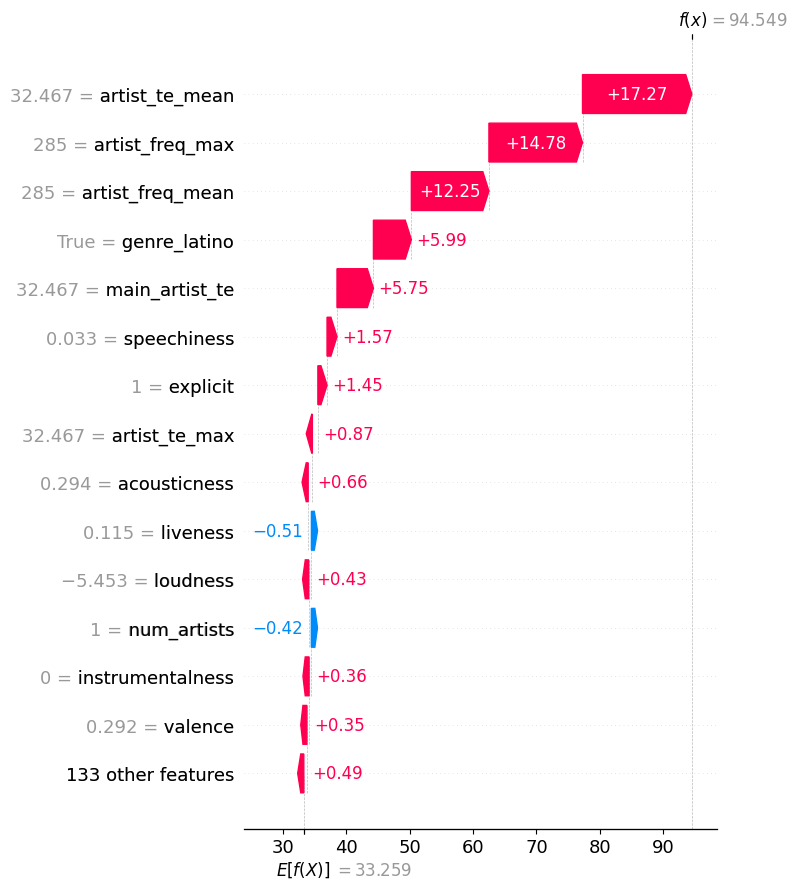

Waterfall explanation: high_predicted_collaboration_song


,feature,feature_value,shap_value
17,artist_te_max,79.5,18.381222
16,artist_te_mean,55.983333,18.063406
15,main_artist_te,32.466667,4.570959
83,genre_reggaeton,True,3.997163
18,artist_freq_mean,144.5,3.890131


,feature,feature_value,shap_value
5,loudness,-10.059,-0.583448
10,liveness,0.113,-0.335532
11,valence,0.145,-0.215354
25,genre_pop,False,-0.077178
3,energy,0.573,-0.073861


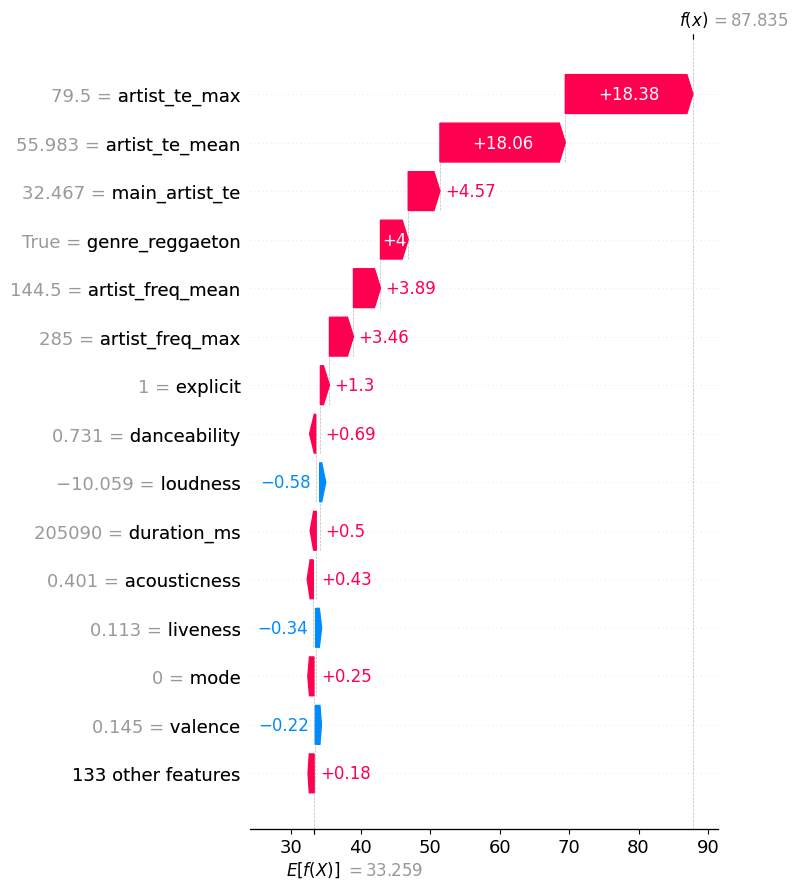

Waterfall explanation: low_predicted_collaboration_song


,feature,feature_value,shap_value
18,artist_freq_mean,98.0,0.670818
19,artist_freq_max,353,0.596508
5,loudness,-5.382,0.243138
140,broad_genre_latin_brazilian,True,0.136326
6,mode,0,0.114018


,feature,feature_value,shap_value
16,artist_te_mean,8.655916,-24.163954
119,genre_latin,True,-5.357531
17,artist_te_max,22.9,-4.636983
15,main_artist_te,17.917847,-4.164488
12,tempo,93.005,-0.454568


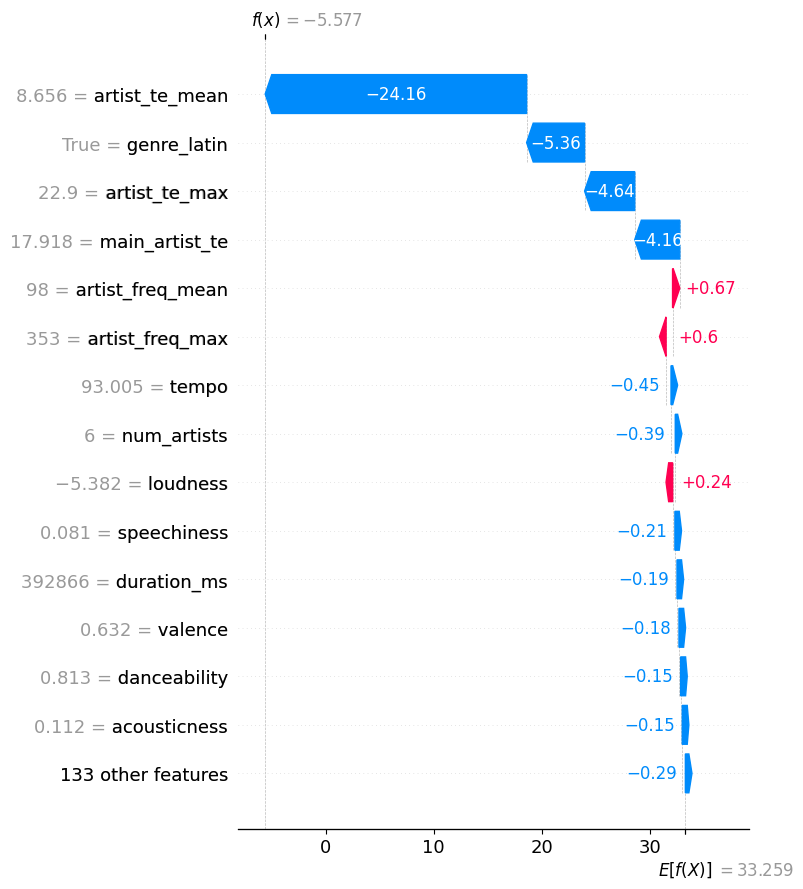

In [26]:
print('Analysis 4: Waterfall plots for selected songs')

analysis4_indices = {
    'high_predicted_single_artist_song': xgb_predictions.loc[X_test['num_artists'] == 1].idxmax(),
    'high_predicted_collaboration_song': xgb_predictions.loc[X_test['num_artists'] > 1].idxmax(),
    'low_predicted_collaboration_song': xgb_predictions.loc[X_test['num_artists'] > 1].idxmin(),
}

analysis4_summary = pd.DataFrame([
    {
        'bucket': bucket,
        'track_name': X_test_raw.loc[idx, 'track_name'],
        'artists': X_test_raw.loc[idx, 'artists'],
        'num_artists': X_test.loc[idx, 'num_artists'],
        'genre': X_test_raw.loc[idx, 'track_genre'],
        'actual_popularity': y_test.loc[idx],
        'predicted_popularity': xgb_predictions.loc[idx],
    }
    for bucket, idx in analysis4_indices.items()
])
display(analysis4_summary)

analysis4_feature_rows = X_test.loc[list(analysis4_indices.values())]
analysis4_explanation = shap_explainer(analysis4_feature_rows)

for row_position, (bucket, idx) in enumerate(analysis4_indices.items()):
    print(f'Waterfall explanation: {bucket}')
    contribution_df = pd.DataFrame({
        'feature': analysis4_feature_rows.columns,
        'feature_value': analysis4_feature_rows.iloc[row_position].values,
        'shap_value': analysis4_explanation.values[row_position],
    })
    top_positive = contribution_df.sort_values('shap_value', ascending=False).head(5)
    top_negative = contribution_df.sort_values('shap_value', ascending=True).head(5)
    display(top_positive)
    display(top_negative)
    try:
        shap.plots.waterfall(analysis4_explanation[row_position], max_display=15, show=False)
        plt.tight_layout()
        plt.show()
    except Exception:
        shap.plots.waterfall(analysis4_explanation[row_position], max_display=10)


Analysis 5: Dependence plots for artist strength and collaboration size


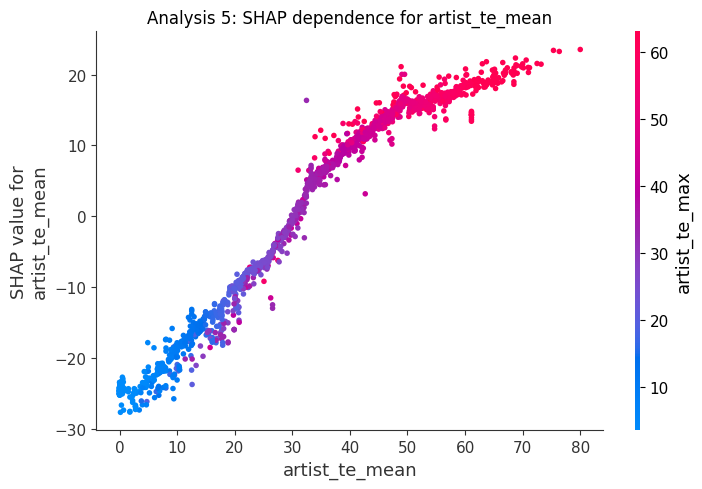

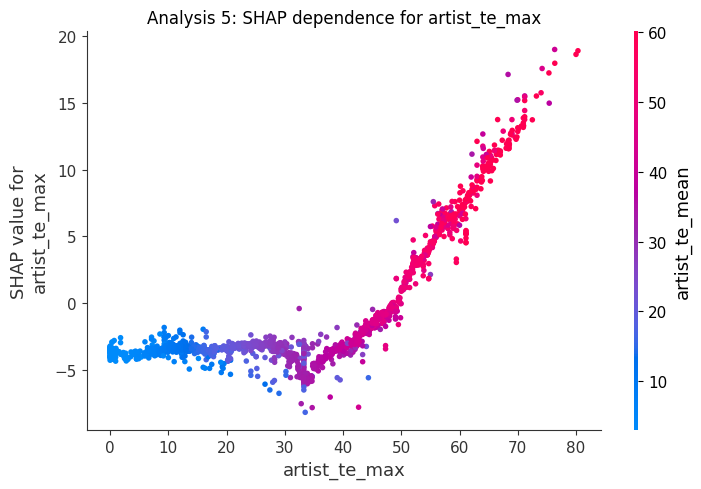

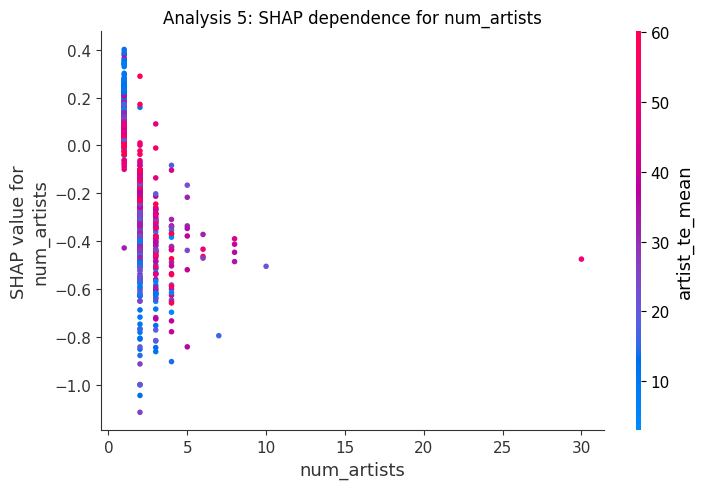

,feature,feature_to_shap_correlation
0,artist_te_mean,0.973069
1,artist_te_max,0.739756
2,num_artists,-0.624840


In [27]:
print('Analysis 5: Dependence plots for artist strength and collaboration size')

analysis5_sample, analysis5_explanation, analysis5_mean_abs = compute_subset_shap(
    X_test,
    sample_limit=2000,
)

analysis5_direction_rows = []
for feature_name in ['artist_te_mean', 'artist_te_max', 'num_artists']:
    shap.dependence_plot(
        feature_name,
        analysis5_explanation.values,
        analysis5_sample,
        interaction_index='auto',
        show=False,
    )
    plt.title(f'Analysis 5: SHAP dependence for {feature_name}')
    plt.tight_layout()
    plt.show()

    analysis5_direction_rows.append({
        'feature': feature_name,
        'feature_to_shap_correlation': summarize_feature_direction(
            feature_name,
            analysis5_sample,
            analysis5_explanation,
        ),
    })

analysis5_direction_summary = pd.DataFrame(analysis5_direction_rows)
display(analysis5_direction_summary)
